### **Importar librerías**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

### **Funciones**

In [2]:
def deteccion_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    if outliers.shape[0] > 0:
        print(f"Variable: {col}")
        print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
        print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
        print(f"Cantidad de outliers: {outliers.shape[0]}\n")
        return outliers
    
    return pd.DataFrame()

### **Parámetros**

In [3]:
# Lista de columnas del dataset
cols_list = [
    "checking_status",
    "duration",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings",
    "employment",
    "installment_rate",
    "personal_status_sex",
    "other_debtors",
    "residence_since",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "people_liable",
    "telephone",
    "foreign_worker",
    "default"
]

In [4]:
# Mapeo de variables
dict_mapping = {
    "checking_status": {
        "A11": "less_0",
        "A12": "0_200",
        "A13": "greater_200",
        "A14": "no_account"
    },
    "credit_history": {
        "A30": "no_credit/all_paid",
        "A31": "all_paid",
        "A32": "existing_paid",
        "A33": "delay",
        "A34": "critical/other"
    },
    "purpose": {
        "A40": "car_new",
        "A41": "car_used",
        "A42": "furniture/equipment",
        "A43": "radio/TV",
        "A44": "domestic_appliances",
        "A45": "repairs",
        "A46": "education",
        "A47": "vacation",
        "A48": "retraining",
        "A49": "business",
        "A410": "others"
    },
    "savings": {
        "A61": "less_100",
        "A62": "100_500",
        "A63": "500_1000",
        "A64": "greater_1000",
        "A65": "unknown"
    },
    "employment": {
        "A71": "unemployed",
        "A72": "less_1",
        "A73": "1_4",
        "A74": "4_7",
        "A75": "greater_7"
    },
    "personal_status_sex": {
        "A91": "male_divorced/separated",
        "A92": "female_divorced/separated/married",
        "A93": "male_single",
        "A94": "male_married",
        "A95": "female_single"
    },
    "other_debtors": {
        "A101": "none",
        "A102": "co_applicant",
        "A103": "guarantor"
    },
    "property": {
        "A121": "real_estate",
        "A122": "building_society_savings_agreement/life_insurance",
        "A123": "car_or_other",
        "A124": "unknown/no_property"
    },
    "other_installment_plans": {
        "A141": "bank",
        "A142": "stores",
        "A143": "none"
    },
    "housing": {
        "A151": "rent",
        "A152": "own",
        "A153": "for_free"
    },
    "job": {
        "A171": "unemployed/unskilled",
        "A172": "unskilled_resident",
        "A173": "skilled/official",
        "A174": "management/self-employed/highly_qualified"
    },
    "telephone": {
        "A191": "none",
        "A192": "yes"
    },
    "foreign_worker": {
        "A201": "yes",
        "A202": "no"
    },
    "default": {
        1: "good",
        2: "bad"
    }
}

In [5]:
# Tipo de datos del dataset
dtype_mapping = {
    "checking_status": "object",
    "duration": "int64",
    "credit_history": "object",
    "purpose": "object",
    "credit_amount": "int64",
    "savings": "object",
    "employment": "object",
    "installment_rate": "int64",
    "personal_status_sex": "object",
    "other_debtors": "object",
    "residence_since": "int64",
    "property": "object",
    "age": "int64",
    "other_installment_plans": "object",
    "housing": "object",
    "existing_credits": "int64",
    "job": "object",
    "people_liable": "int64",
    "telephone": "object",
    "foreign_worker": "object",
    "default": "object"
}

### **Cargar datos**

In [6]:
df = pd.read_csv(
    "german.data",
    sep=" ",
    header=None,
    names=cols_list
)

print(f"Cantidad de filas: {df.shape[0]}")
print(f"Cantidad de columnas: {df.shape[1]}")

df.head()

Cantidad de filas: 1000
Cantidad de columnas: 21


,checking_status,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,default
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


### **Preprocesamiento de datos**

In [7]:
# Mapeo de variables categóricas
for col, mapping in dict_mapping.items():
    df[col] = df[col].map(mapping)

df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,default
0,less_0,6,critical/other,radio/TV,1169,unknown,greater_7,4,male_single,none,...,real_estate,67,none,own,2,skilled/official,1,yes,yes,good
1,0_200,48,existing_paid,radio/TV,5951,less_100,1_4,2,female_divorced/separated/married,none,...,real_estate,22,none,own,1,skilled/official,1,none,yes,bad
2,no_account,12,critical/other,education,2096,less_100,4_7,2,male_single,none,...,real_estate,49,none,own,1,unskilled_resident,2,none,yes,good
3,less_0,42,existing_paid,furniture/equipment,7882,less_100,4_7,2,male_single,guarantor,...,building_society_savings_agreement/life_insurance,45,none,for_free,1,skilled/official,2,none,yes,good
4,less_0,24,delay,car_new,4870,less_100,1_4,3,male_single,none,...,unknown/no_property,53,none,for_free,2,skilled/official,2,none,yes,bad


In [8]:
# Información del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   checking_status          1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment               1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [9]:
# Revisar que los tipos de datos sean correctos
cont = 0
for col, dtype in dtype_mapping.items():
    if df[col].dtype != dtype:
        print(f"Columna '{col}' tiene tipo de dato '{df[col].dtype}' pero se esperaba '{dtype}'")
    else:
        cont += 1

print(f"Total de columnas con tipo de dato correcto: {cont}")

if cont == len(dtype_mapping):
    print("Todos los tipos de datos son correctos.")
else:
    raise ValueError("Algunos tipos de datos no son correctos. Revisar el mensaje anterior para más detalles.")

Total de columnas con tipo de dato correcto: 21
Todos los tipos de datos son correctos.


In [10]:
# Revisar duplicados
num_duplicates = df.duplicated().sum()

if num_duplicates > 0:
    print(f"Cantidad de filas duplicadas: {num_duplicates}")
    df = df.drop_duplicates()
    print("Filas duplicadas eliminadas.")
else:
    print("No se encontraron filas duplicadas.")

No se encontraron filas duplicadas.


In [11]:
# Revisar datos faltantes
missing_values = df.isnull().sum()

print("Cantidad de valores faltantes por columna:")
print(missing_values)

Cantidad de valores faltantes por columna:
checking_status            0
duration                   0
credit_history             0
purpose                    0
credit_amount              0
savings                    0
employment                 0
installment_rate           0
personal_status_sex        0
other_debtors              0
residence_since            0
property                   0
age                        0
other_installment_plans    0
housing                    0
existing_credits           0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
default                    0
dtype: int64


In [12]:
# Resumen estadístico del dataset
print("Resumen estadístico de las variables numéricas:")
display(df.describe(include="number"))

print("Resumen estadístico de las variables categóricas:")
display(df.describe(include="object").T)

Resumen estadístico de las variables numéricas:


,duration,credit_amount,installment_rate,residence_since,age,existing_credits,people_liable
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


Resumen estadístico de las variables categóricas:


,count,unique,top,freq
checking_status,1000,4,no_account,394
credit_history,1000,5,existing_paid,530
purpose,1000,10,radio/TV,280
savings,1000,5,less_100,603
employment,1000,5,1_4,339
personal_status_sex,1000,4,male_single,548
other_debtors,1000,3,none,907
property,1000,4,car_or_other,332
other_installment_plans,1000,3,none,814
housing,1000,3,own,713


### **Análisis exploratorio**

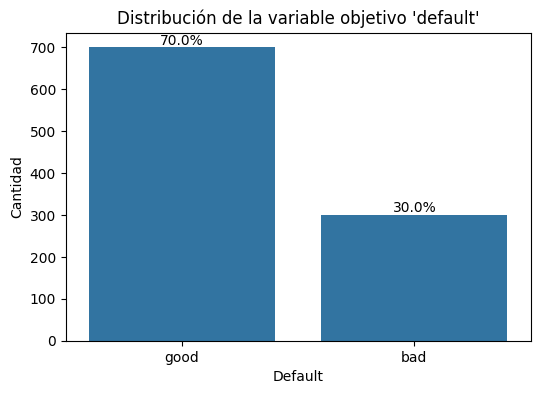

In [13]:
# Distribución de la variable objetivo
plt.figure(figsize=(6, 4))
sns.countplot(x="default", data=df)

# Agregar etiquetas (porcentajes)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height() / len(df) * 100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.title("Distribución de la variable objetivo 'default'")
plt.xlabel("Default")
plt.ylabel("Cantidad")
plt.show()

Hay un poco de desbalanceo en la variable objetivo, en el que "good" es predominante

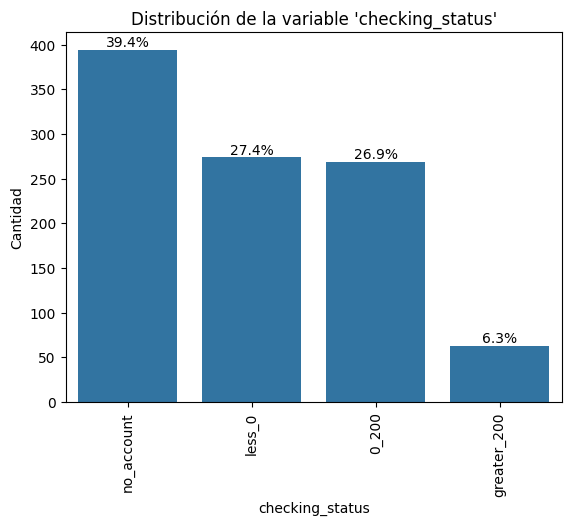

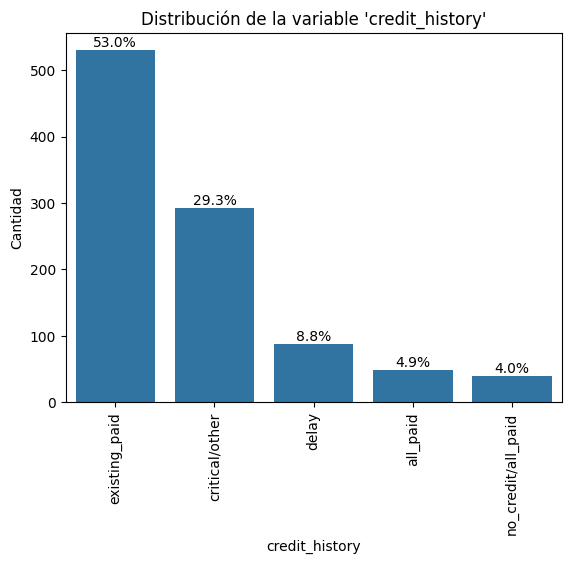

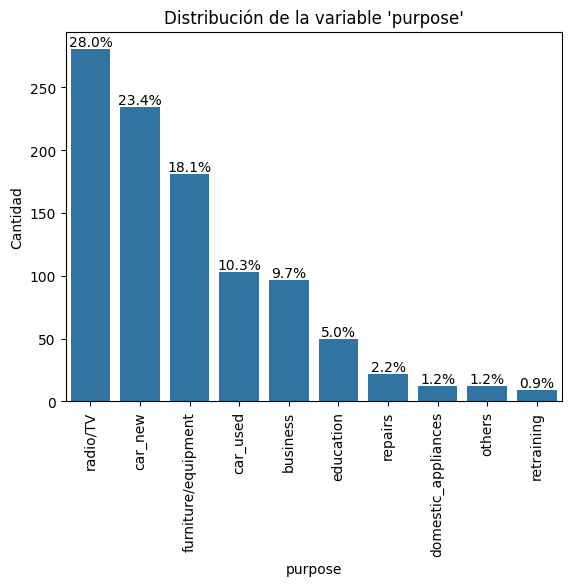

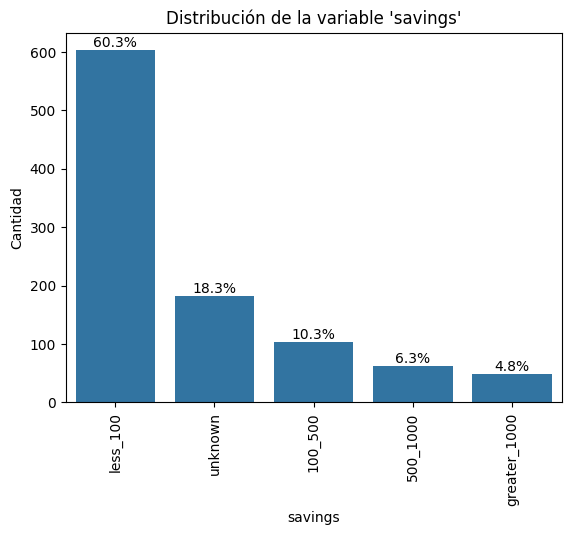

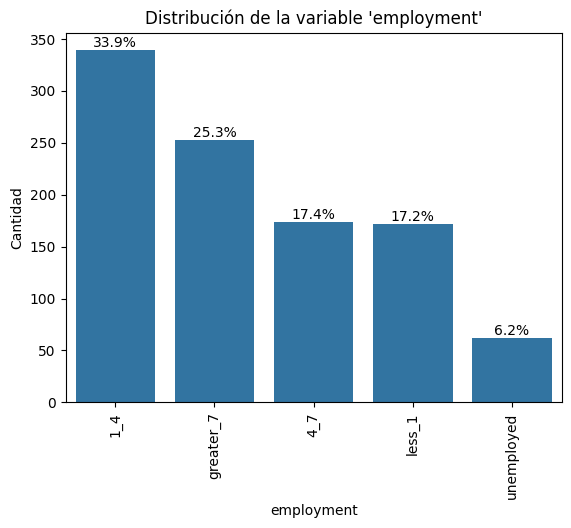

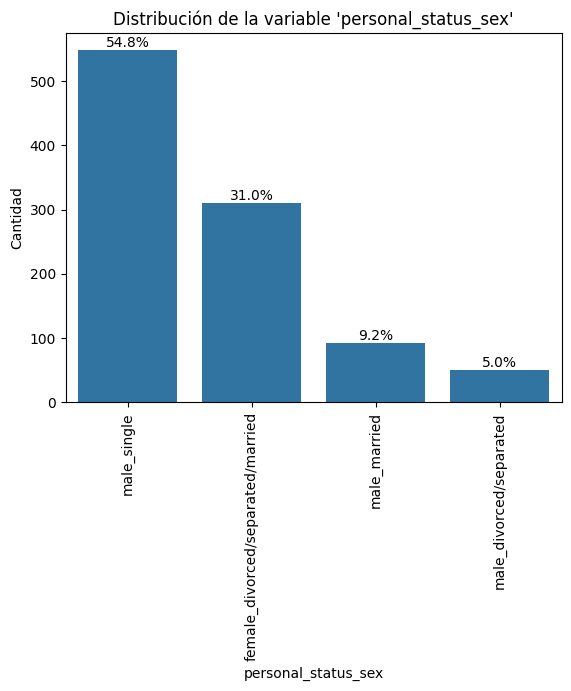

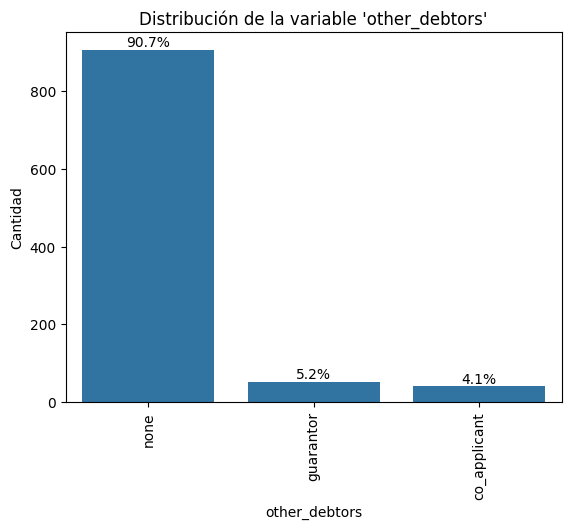

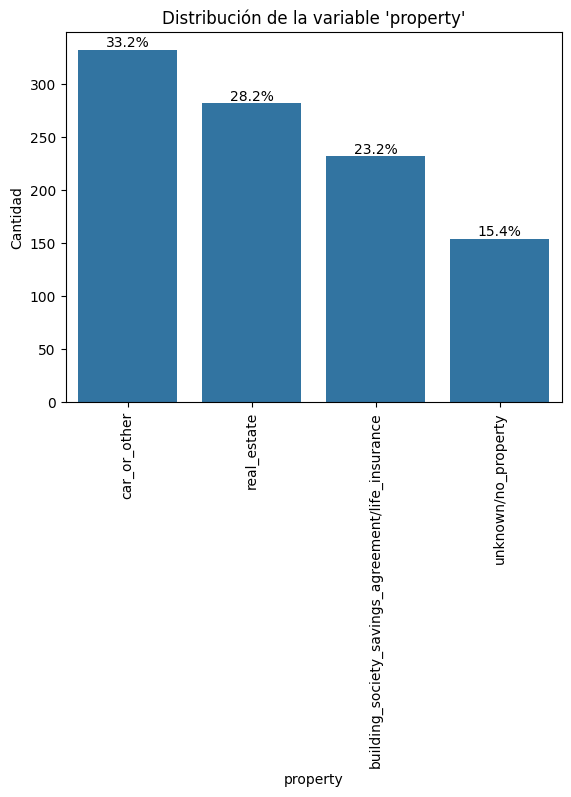

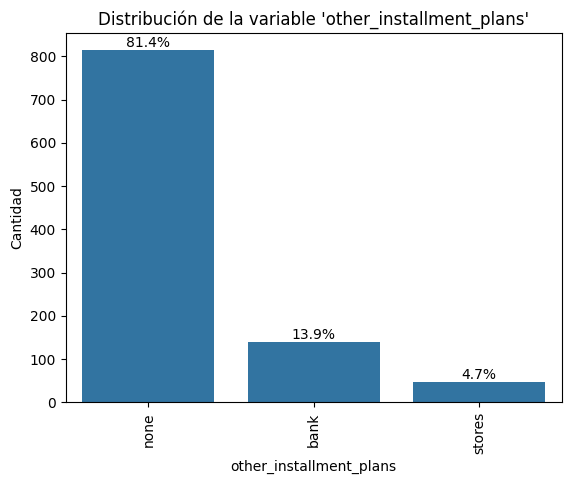

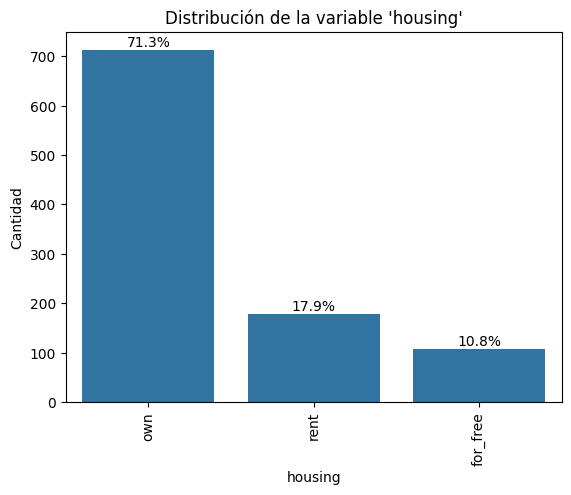

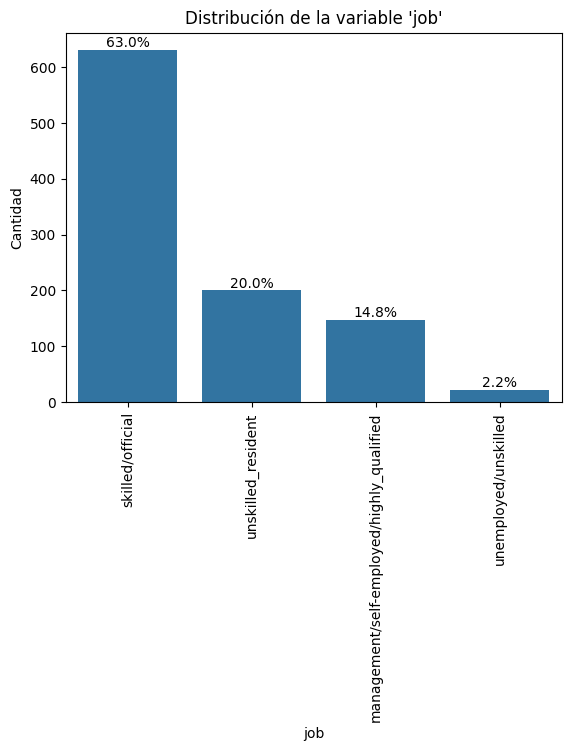

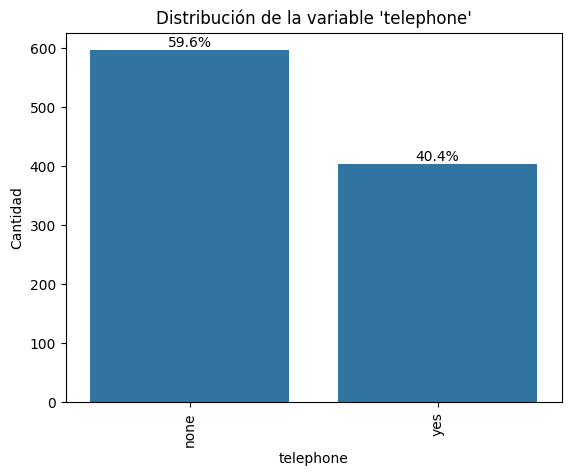

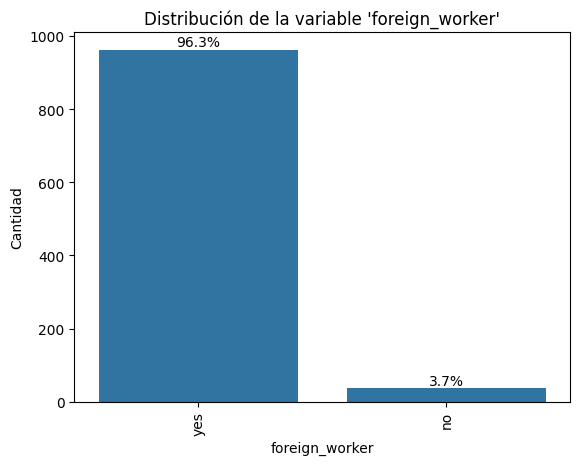

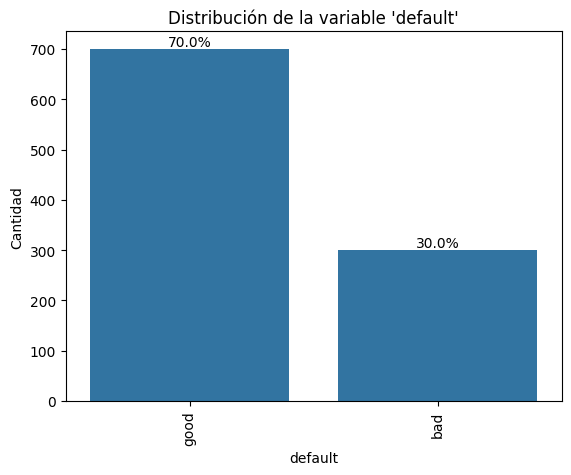

In [14]:
# Análisis descriptivo de las variables categóricas
categorical_cols = df.select_dtypes(include="object").columns

for i, col in enumerate(categorical_cols):
    # 1. Obtener las categorías ordenadas de mayor a menor frecuencia
    orden_categorias = df[col].value_counts().index
    
    # 2. Usar el parámetro 'order' en countplot
    sns.countplot(x=col, data=df, order=orden_categorias)
    
    # Agregar etiquetas (porcentajes)
    for p in plt.gca().patches:
        altura = p.get_height()
        # Evitar errores si alguna barra tiene altura 0 o NaN
        if altura > 0: 
            plt.gca().annotate(f'{altura / len(df) * 100:.1f}%', 
                               (p.get_x() + p.get_width() / 2., altura), 
                               ha='center', va='center', 
                               xytext=(0, 5), textcoords='offset points')

    # Eliminamos la línea problemática: plt.gca().patches.sort(...)

    plt.title(f"Distribución de la variable '{col}'")
    plt.xlabel(col)
    plt.ylabel("Cantidad")
    plt.xticks(rotation=90)
    plt.show()

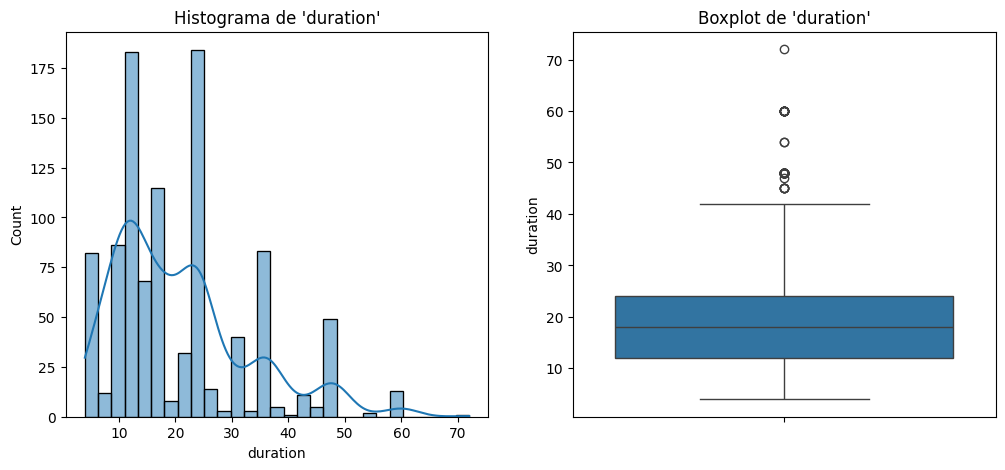

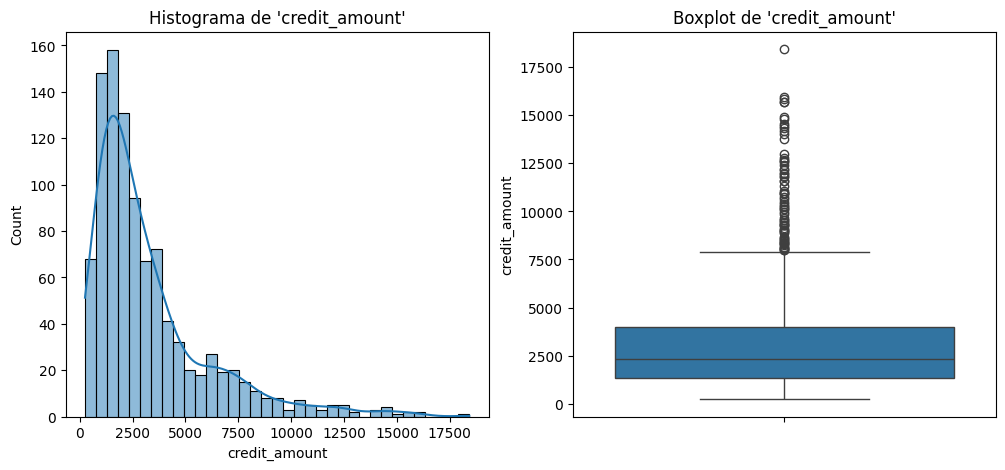

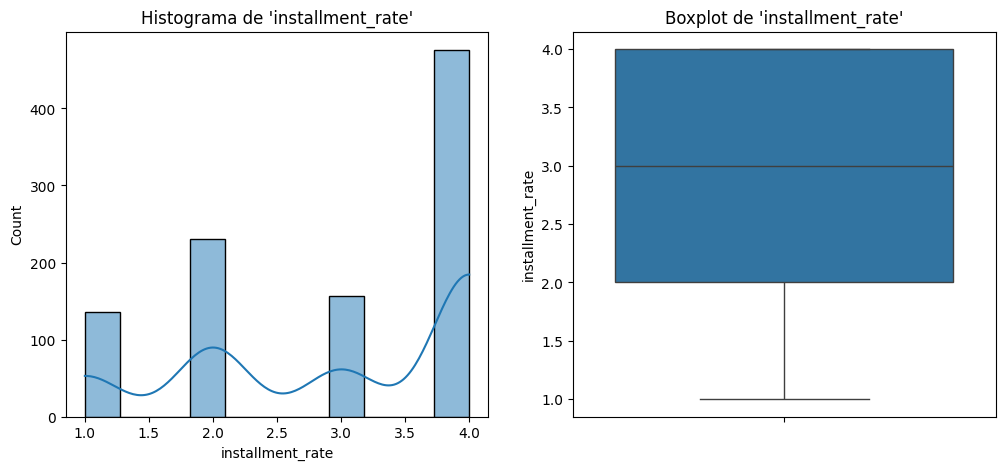

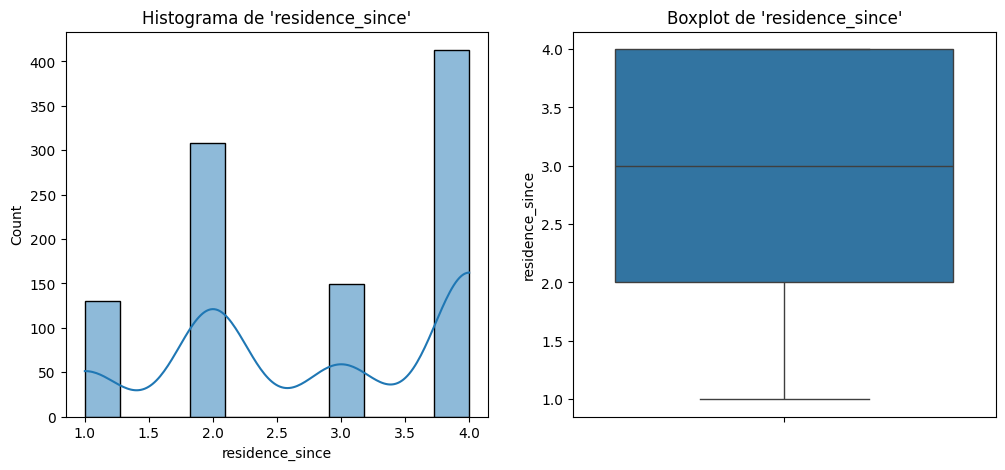

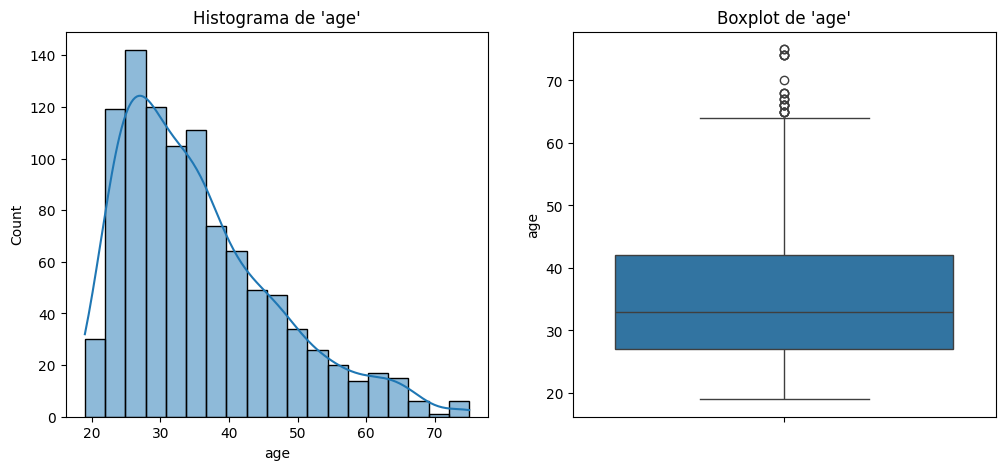

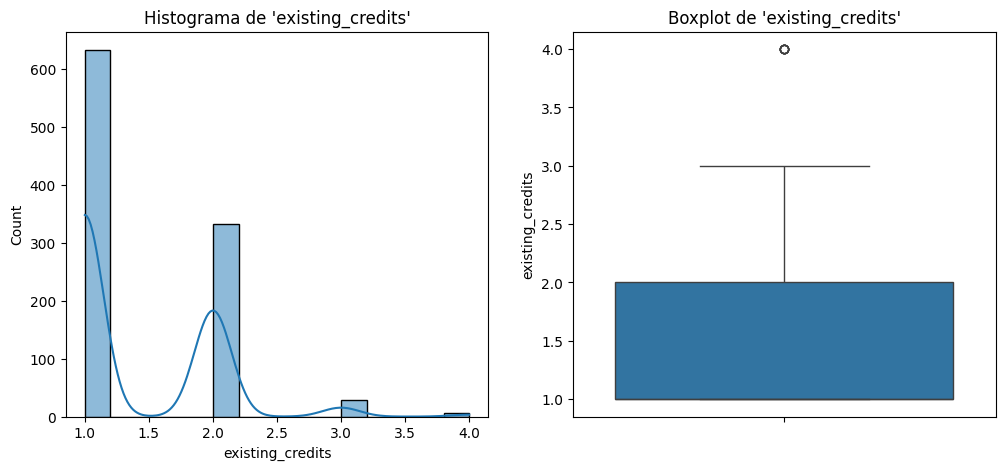

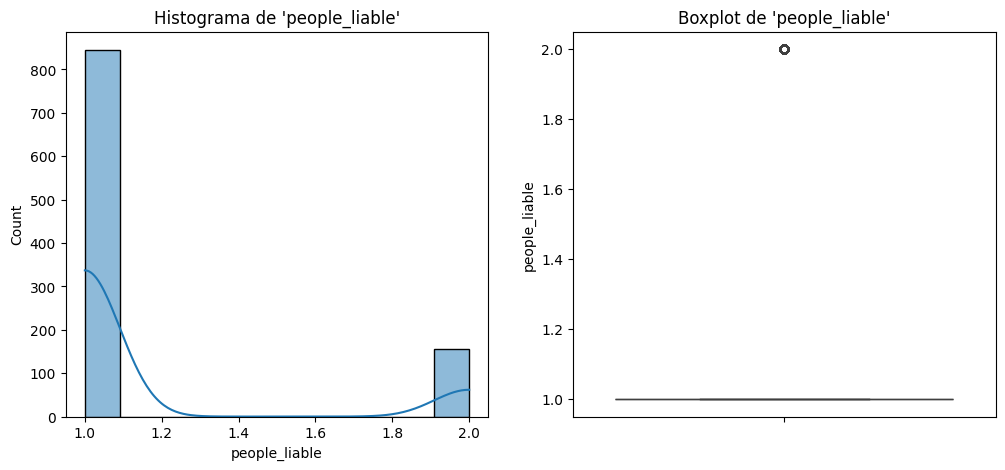

In [15]:
# Análisis descriptivo de las variables numéricas
num_cols = df.select_dtypes(include="number").columns
for col in num_cols:
    plt.figure(figsize=(12, 5))
    
    # Histograma
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Histograma de '{col}'")
    
    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot de '{col}'")
    
    plt.show()

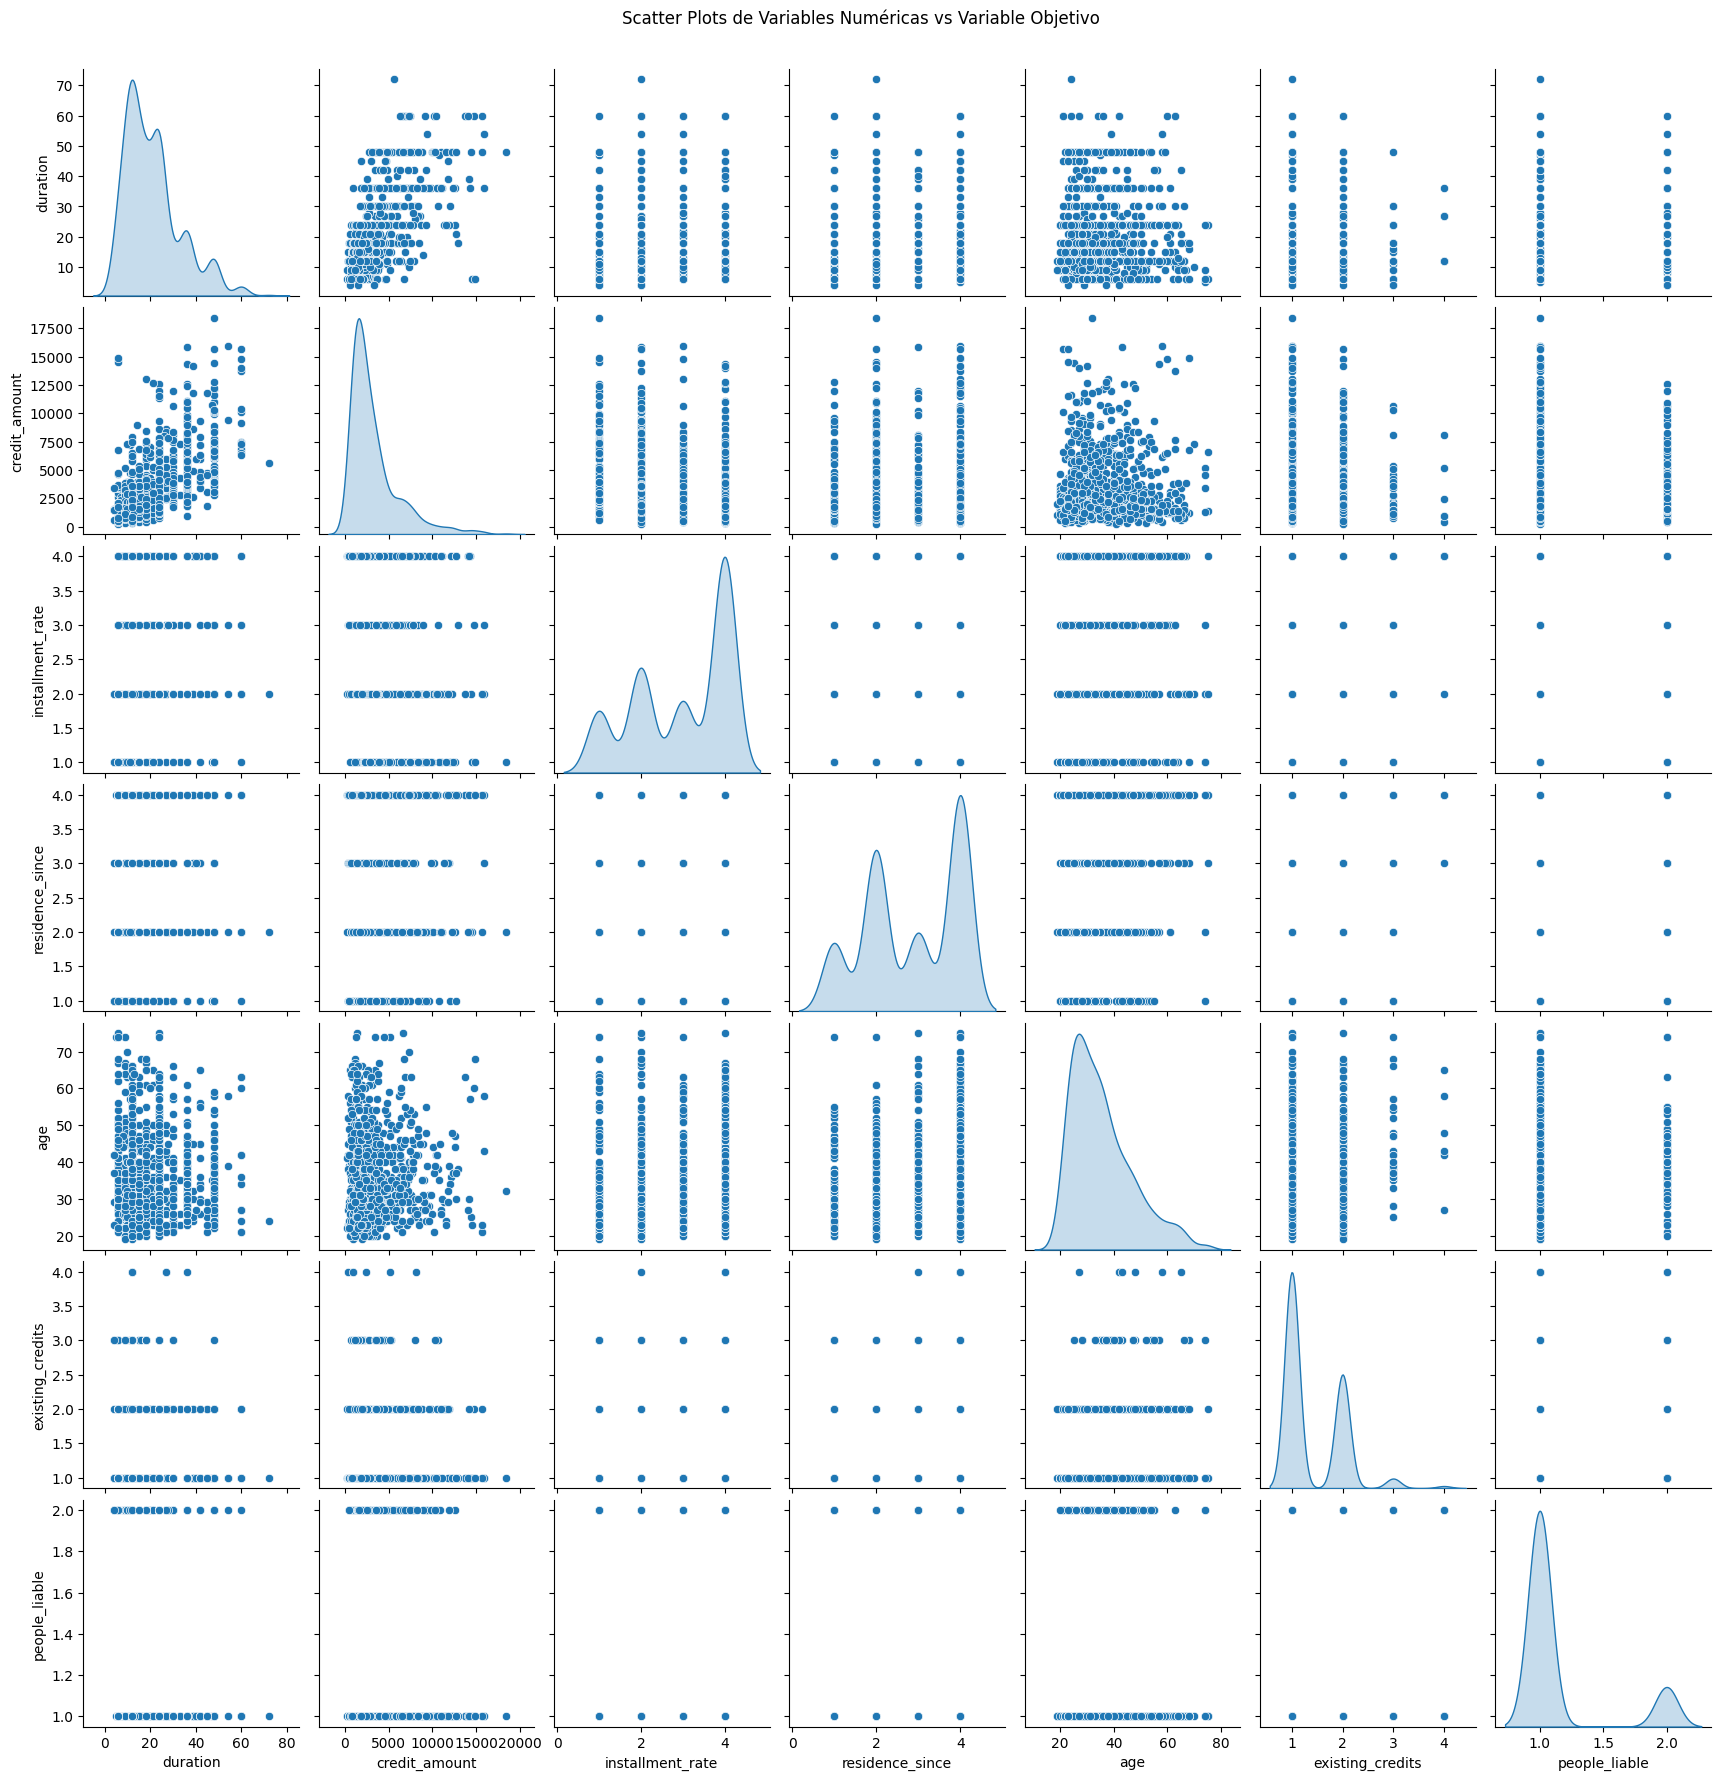

In [16]:
# Scatter plots para variables numéricas vs variable objetivo
numerical_cols = df.select_dtypes(include="number").columns
sns.pairplot(df, vars=numerical_cols, diag_kind="kde")
plt.suptitle("Scatter Plots de Variables Numéricas vs Variable Objetivo", y=1.02)
plt.show()

In [17]:
# Detección e imputación de valores atípicos
for col in numerical_cols:
    # Detectar outliers
    ## Método Tukey (IQR)
    outliers = deteccion_outliers_iqr(df, col)

Variable: duration
Q1: 12.0, Q3: 24.0, IQR: 12.0
Lower Bound: -6.0, Upper Bound: 42.0
Cantidad de outliers: 70

Variable: credit_amount
Q1: 1365.5, Q3: 3972.25, IQR: 2606.75
Lower Bound: -2544.625, Upper Bound: 7882.375
Cantidad de outliers: 72

Variable: age
Q1: 27.0, Q3: 42.0, IQR: 15.0
Lower Bound: 4.5, Upper Bound: 64.5
Cantidad de outliers: 23

Variable: existing_credits
Q1: 1.0, Q3: 2.0, IQR: 1.0
Lower Bound: -0.5, Upper Bound: 3.5
Cantidad de outliers: 6

Variable: people_liable
Q1: 1.0, Q3: 1.0, IQR: 0.0
Lower Bound: 1.0, Upper Bound: 1.0
Cantidad de outliers: 155



Revisar qué hacer con los posibles atípicos

In [ ]:
# Análisis de correlación entre variables numéricas (dataset sin outliers)
numerical_cols = df.select_dtypes(include="number").columns
correlation_matrix = df[numerical_cols].corr()

# Calcular p-values para la matriz de correlación
p_values = df[numerical_cols].corr(method=lambda x, y: pearsonr(x, y)[1])

# Visualizar la matriz de correlación,
# difumando las correlaciones no significativas (p-value >= 0.05)
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm",
    mask=p_values >= 0.05, vmin=-1, vmax=1, cbar_kws={"shrink": .8}
)
plt.title("Matriz de Correlación")
plt.show()

In [ ]:
# Scatter plots para variables numéricas vs variable objetivo
sns.pairplot(df, vars=numerical_cols, hue="default", diag_kind="kde")
plt.suptitle("Scatter Plots de Variables Numéricas vs Variable Objetivo", y=1.02)
plt.show()

In [ ]:
# Boxplots de variables numéricas vs variable objetivo
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="default", y=col, data=df)
    plt.title(f"Boxplot de '{col}' vs 'default'")
    plt.xlabel("Default")
    plt.ylabel(col)
    plt.show()

In [ ]:
# Análisis variables categóricas vs variable objetivo
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue="default", data=df)
    plt.title(f"Distribución de '{col}' vs 'default'")
    plt.xlabel(col)
    plt.ylabel("Cantidad")
    plt.xticks(rotation=90)
    plt.legend(title="Default")
    plt.show()